#Carga de datos

In [ ]:
!git clone https://github.com/llosaba/SOM_Project.git


Cloning into 'SOM_Project'...
remote: Enumerating objects: 573, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 573 (delta 21), reused 0 (delta 0), pack-reused 507 (from 1)
Receiving objects: 100% (573/573), 796.45 KiB | 8.04 MiB/s, done.
Resolving deltas: 100% (81/81), done.


In [ ]:
!ls SOM_Project/BBDD/Passing


 Bundesliga  'La Liga'	'Ligue 1'  'Premier league'  'Serie A'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from minisom import MiniSom
from scipy.cluster.hierarchy import linkage, fcluster

#Passing nada más


In [ ]:
import pandas as pd
from pathlib import Path

base_path = Path("/content/SOM_Project/BBDD/Passing")

dfs = []

for league_dir in base_path.iterdir():
    for team_csv in league_dir.glob("*.csv"):
        try:
            df = pd.read_csv(
                team_csv,
                encoding="utf-16",
                sep=None,          # <-- DETECCIÓN AUTOMÁTICA
                engine="python"    # <-- CLAVE
            )
        except:
            df = pd.read_csv(
                team_csv,
                encoding="latin1",
                sep=None,
                engine="python"
            )

        df["League"] = league_dir.name
        df["TeamFile"] = team_csv.stem
        dfs.append(df)

passing_df = pd.concat(dfs, ignore_index=True)

passing_df.head()



,Player,Nation,Pos,Age,90s,Cmp,Att,Cmp%,TotDist,PrgDist,...,xA,A-xA,KP,1/3,PPA,CrsPA,Prog,Matches,League,TeamFile
0,Raúl Albiol\Raul-Albiol,es ESP,DF,33.0,26.0,1169.0,1353.0,86.4,30720.0,8949.0,...,0.3,-0.3,4.0,79.0,5.0,1.0,64.0,Matches,La Liga,Villarreal
1,Vicente Iborra\Vicente-Iborra,es ESP,MF,31.0,23.5,1002.0,1157.0,86.6,20777.0,4636.0,...,0.3,1.7,5.0,93.0,4.0,0.0,72.0,Matches,La Liga,Villarreal
2,Sergio Asenjo\Sergio-Asenjo,es ESP,GK,30.0,24.0,528.0,729.0,72.4,15782.0,8797.0,...,0.0,0.0,0.0,6.0,0.0,0.0,0.0,Matches,La Liga,Villarreal
3,Gerard Moreno\Gerard-Moreno,es ESP,FWMF,27.0,22.9,558.0,768.0,72.7,11055.0,2724.0,...,4.2,-1.2,40.0,57.0,31.0,9.0,83.0,Matches,La Liga,Villarreal
4,Pau Torres\Pau-Torres,es ESP,DF,22.0,23.0,1189.0,1395.0,85.2,28990.0,9133.0,...,1.3,-0.3,6.0,75.0,1.0,0.0,69.0,Matches,La Liga,Villarreal


##Limpieza

In [ ]:
# '90s' es la columna de tiempo
time_col = "90s"

# Filtrar jugadores con poco tiempo
passing_df = passing_df[passing_df[time_col] >= 2]
meta_df = meta_df.loc[passing_df.index]

# Normalizar por tiempo jugado
stats_cols = [c for c in passing_df.columns if c != time_col]

passing_df[stats_cols] = passing_df[stats_cols].div(
    passing_df[time_col], axis=0
)

#eliminar '90s' si no quieres volumen
passing_df = passing_df.drop(columns=[time_col])


/tmp/ipython-input-1760972545.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passing_df[stats_cols] = passing_df[stats_cols].div(


In [ ]:
passing_df


,Cmp,Att,Cmp%,TotDist,PrgDist,Cmp.1,Att.1,Cmp%.1,Cmp.2,Att.2,...,Att.3,Cmp%.3,Ast,xA,A-xA,KP,1/3,PPA,CrsPA,Prog
0,44.961538,52.038462,3.323077,1181.538462,344.192308,0.153846,0.461538,1.280769,21.576923,23.653846,...,27.923077,3.200000,0.000000,0.011538,-0.011538,0.153846,3.038462,0.192308,0.038462,2.461538
1,42.638298,49.234043,3.685106,884.127660,197.276596,0.638298,1.148936,2.365957,30.212766,33.702128,...,14.382979,3.489362,0.085106,0.012766,0.072340,0.212766,3.957447,0.170213,0.000000,3.063830
2,22.000000,30.375000,3.016667,657.583333,366.541667,0.083333,0.083333,4.166667,11.083333,11.166667,...,19.125000,2.358333,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000
3,24.366812,33.537118,3.174672,482.751092,118.951965,0.480349,2.052402,1.021834,17.772926,22.532751,...,8.951965,2.982533,0.131004,0.183406,-0.052402,1.746725,2.489083,1.353712,0.393013,3.624454
4,51.695652,60.652174,3.704348,1260.434783,397.086957,0.434783,0.956522,1.978261,29.739130,31.956522,...,27.739130,3.373913,0.043478,0.056522,-0.013043,0.260870,3.260870,0.043478,0.000000,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2728,16.750000,29.750000,14.075000,272.000000,149.000000,0.000000,0.750000,0.000000,14.250000,20.250000,...,8.750000,7.150000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.250000,2.250000
2729,13.846154,25.000000,21.307692,228.076923,81.153846,0.000000,0.769231,0.000000,12.307692,20.384615,...,3.846154,15.384615,0.000000,0.000000,0.000000,0.000000,0.769231,0.000000,0.000000,1.153846
2730,16.000000,22.500000,35.550000,310.000000,168.000000,0.000000,2.500000,0.000000,12.500000,14.500000,...,5.500000,31.800000,0.000000,0.200000,-0.200000,1.000000,2.000000,2.000000,0.500000,4.000000
2731,11.000000,20.000000,27.500000,622.000000,546.500000,0.000000,0.000000,0.000000,1.000000,1.000000,...,19.000000,26.300000,0.000000,0.000000,0.000000,0.000000,1.500000,0.000000,0.000000,0.000000


##Modelo

Escalado y ENTRENAMIENTO DEL SELF-ORGANIZING MAP (SOM)

In [ ]:
#ESCALADO DE VARIABLES (REQUERIDO PARA SOM)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(passing_df)

#SOM
!pip install minisom
from minisom import MiniSom

#Creación el SOM con la topología del artículo (4x5)
som = MiniSom(
    x=4,                      # número de filas del mapa
    y=5,                      # número de columnas del mapa
    input_len=X.shape[1],     # número de variables
    sigma=1.0,                # radio del vecindario
    learning_rate=0.5,        # tasa de aprendizaje
    neighborhood_function="bubble",  # igual al paper
    random_seed=42            # reproducibilidad
)

# Inicializamos pesos aleatoriamente
som.random_weights_init(X)

# Entrenamos el SOM usando muestreo aleatorio
# 1000 iteraciones es lo que reporta el artículo
som.train_random(X, num_iteration=1000)

CÁLCULO DE LA U-MATRIX

In [ ]:
import numpy as np

# La U-Matrix muestra distancias entre neuronas vecinas
u_matrix = som.distance_map()

u_matrix


#EXTRAER LOS PESOS DE LAS NEURONAS



array([[0.37426229, 0.51310777, 0.64808699, 0.50368491, 0.38647627],
       [0.76218398, 1.        , 0.6875614 , 0.75173462, 0.59521663],
       [0.6219896 , 0.80258347, 0.69710918, 0.93222693, 0.43690798],
       [0.28796737, 0.45229781, 0.47434069, 0.64664755, 0.28336246]])

In [ ]:
#CLUSTERING JERÁRQUICO SOBRE LAS NEURONAS (WARD)

# EXTRAER LOS PESOS DE LAS NEURONAS y darles la forma adecuada
weights = som.get_weights()
weights_reshaped = weights.reshape(-1, X.shape[1])

# Aplicamos clustering jerárquico usando el método Ward
Z = linkage(weights_reshaped, method="ward")

# Cortamos el dendrograma en 6 clusters (valor usado en el artículo)
n_clusters = 6
clusters = fcluster(Z, t=n_clusters, criterion="maxclust")

In [ ]:
#Asignar un cluster a cada jugador
# Obtenemos la neurona ganadora (BMU) de cada jugador
bmus = np.array([som.winner(x) for x in X])

# Convertimos coordenadas (i,j) a índice lineal
bmu_indices = np.array([i * som._weights.shape[1] + j for i, j in bmus])

# Asignamos cluster según la neurona correspondiente
player_clusters = clusters[bmu_indices]


In [ ]:
#dataset final
# Creamos un DataFrame final con las estadísticas normalizadas
final_df = passing_df.copy()
final_df["Cluster"] = player_clusters

final_df.head()


,Cmp,Att,Cmp%,TotDist,PrgDist,Cmp.1,Att.1,Cmp%.1,Cmp.2,Att.2,...,Cmp%.3,Ast,xA,A-xA,KP,1/3,PPA,CrsPA,Prog,Cluster
0,44.961538,52.038462,3.323077,1181.538462,344.192308,0.153846,0.461538,1.280769,21.576923,23.653846,...,3.200000,0.000000,0.011538,-0.011538,0.153846,3.038462,0.192308,0.038462,2.461538,6
1,42.638298,49.234043,3.685106,884.127660,197.276596,0.638298,1.148936,2.365957,30.212766,33.702128,...,3.489362,0.085106,0.012766,0.072340,0.212766,3.957447,0.170213,0.000000,3.063830,6
2,22.000000,30.375000,3.016667,657.583333,366.541667,0.083333,0.083333,4.166667,11.083333,11.166667,...,2.358333,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,6
3,24.366812,33.537118,3.174672,482.751092,118.951965,0.480349,2.052402,1.021834,17.772926,22.532751,...,2.982533,0.131004,0.183406,-0.052402,1.746725,2.489083,1.353712,0.393013,3.624454,5
4,51.695652,60.652174,3.704348,1260.434783,397.086957,0.434783,0.956522,1.978261,29.739130,31.956522,...,3.373913,0.043478,0.056522,-0.013043,0.260870,3.260870,0.043478,0.000000,3.000000,6


##Resultados

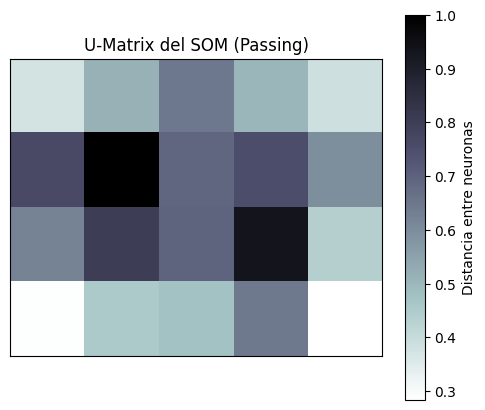

In [ ]:
# Obtenemos la matriz de distancias del SOM
u_matrix = som.distance_map()

# Creamos la figura
plt.figure(figsize=(6, 5))

# Mostramos la U-Matrix como mapa de calor
plt.imshow(u_matrix, cmap="bone_r")

# Barra de color para interpretar distancias
plt.colorbar(label="Distancia entre neuronas")

# Quitamos ejes (estilo paper)
plt.xticks([])
plt.yticks([])

plt.title("U-Matrix del SOM (Passing)")
plt.show()


In [ ]:
#ASIGNAR CLUSTERS A JUGADORES

# Copiamos metadatos para no modificarlos
players = meta_df.copy()

# Añadimos el cluster asignado
players["Cluster"] = final_df["Cluster"].values

# Mostramos algunos jugadores con su cluster
players.head()


,Player,Nation,Pos,Age,League,TeamFile,Cluster
0,Raúl Albiol\Raul-Albiol,es ESP,DF,33.0,La Liga,Villarreal,6
1,Vicente Iborra\Vicente-Iborra,es ESP,MF,31.0,La Liga,Villarreal,6
2,Sergio Asenjo\Sergio-Asenjo,es ESP,GK,30.0,La Liga,Villarreal,6
3,Gerard Moreno\Gerard-Moreno,es ESP,FWMF,27.0,La Liga,Villarreal,5
4,Pau Torres\Pau-Torres,es ESP,DF,22.0,La Liga,Villarreal,6


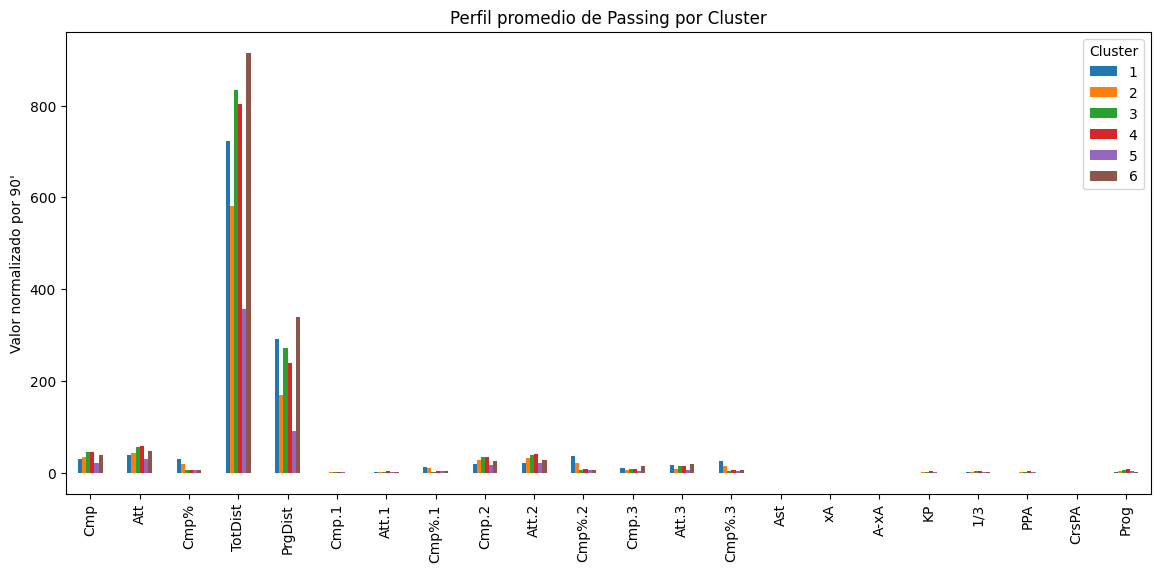

In [ ]:
#Interpretación de los cluster
# Unimos estadísticas + cluster
analysis_df = final_df.copy()
analysis_df["Cluster"] = players["Cluster"].values

# Calculamos la media por cluster
cluster_profiles = analysis_df.groupby("Cluster").mean()

cluster_profiles.T.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Perfil promedio de Passing por Cluster")
plt.ylabel("Valor normalizado por 90'")
plt.legend(title="Cluster")
plt.show()


In [ ]:
#Validación cualitativa

# Tabla cruzada Cluster vs Posición
position_cluster = (
    players
    .groupby(["Cluster", "Pos"])
    .size()
    .unstack(fill_value=0)
)

position_cluster

# Normalizamos por filas (por cluster)
position_cluster_norm = position_cluster.div(
    position_cluster.sum(axis=1),
    axis=0
)

position_cluster_norm


Pos,DF,DFFW,DFMF,FW,FWDF,FWMF,GK,GKFW,MF,MFDF,MFFW
Cluster,,,,,,,,,,,
1,0.472222,0.000000,0.027778,0.013889,0.000000,0.000000,0.347222,0.013889,0.097222,0.000000,0.027778
2,0.271100,0.015345,0.017903,0.143223,0.010230,0.115090,0.010230,0.000000,0.286445,0.012788,0.117647
3,0.444444,0.013072,0.044118,0.004902,0.001634,0.019608,0.000000,0.000000,0.379085,0.032680,0.060458
4,0.000000,0.000000,0.000000,0.130435,0.000000,0.347826,0.000000,0.000000,0.304348,0.000000,0.217391
5,0.038655,0.005042,0.008403,0.389916,0.018487,0.236975,0.000000,0.000000,0.147899,0.008403,0.146218
6,0.616906,0.000000,0.035971,0.000000,0.000000,0.000000,0.241007,0.000000,0.079137,0.026978,0.000000


#Todos

In [ ]:
def load_category(category):
    base_path = Path(f"/content/SOM_Project/BBDD/{category}")
    dfs = []

    for league_dir in base_path.iterdir():
        for team_csv in league_dir.glob("*.csv"):
            try:
                df = pd.read_csv(team_csv, encoding="utf-16", sep=None, engine="python")
            except:
                df = pd.read_csv(team_csv, encoding="latin1", sep=None, engine="python")

            dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

passing_df     = load_category("Passing")
defense_df     = load_category("Defensive")
shooting_df    = load_category("Shooting")
possession_df  = load_category("Possession")

In [ ]:
# Columnas comunes que sirven como identificadores
id_cols = ["Player", "Pos", "Age"]

# Función para limpiar cada categoría
def clean_category(df):
    # Eliminar columnas basura
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Convertir a numérico cuando se pueda
    df = df.apply(pd.to_numeric, errors="ignore")

    return df

passing_df    = clean_category(passing_df)
defense_df    = clean_category(defense_df)
shooting_df   = clean_category(shooting_df)
possession_df = clean_category(possession_df)



/tmp/ipython-input-3391889183.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


In [ ]:
#Unir TODAS las categorías (merge por jugador)
# Merge progresivo para construir el dataset total

# Define common columns that are not part of id_cols and can cause conflicts
# if not handled explicitly during merges. We will keep these from the first DataFrame (passing_df)
# and drop them from the subsequent dataframes before merging.
columns_to_drop_from_subsequent_dfs = ["Nation", "90s", "Matches"]

# Create processed copies of the dataframes by dropping the conflicting columns
defense_df_processed = defense_df.drop(columns=columns_to_drop_from_subsequent_dfs, errors='ignore')
shooting_df_processed = shooting_df.drop(columns=columns_to_drop_from_subsequent_dfs, errors='ignore')
possession_df_processed = possession_df.drop(columns=columns_to_drop_from_subsequent_dfs, errors='ignore')

# Perform merges using the processed dataframes
total_df = passing_df.merge(defense_df_processed, on=id_cols, how="inner")
total_df = total_df.merge(shooting_df_processed, on=id_cols, how="inner")
total_df = total_df.merge(possession_df_processed, on=id_cols, how="inner")

In [ ]:
#Normalización

# Detectamos la columna de tiempo
time_col = "90s"

# Filtramos jugadores con poco tiempo
total_df = total_df[total_df[time_col] >= 2]

# Convertimos todo a numérico
total_df = total_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Normalizamos por tiempo jugado
stats_cols = [c for c in total_df.columns if c not in id_cols + [time_col]]

total_df[stats_cols] = total_df[stats_cols].div(
    total_df[time_col], axis=0
)

# Quitamos columna de volumen
total_df = total_df.drop(columns=[time_col])


In [ ]:
#Escalado + SOM + clustering
# Escalado
scaler_total = MinMaxScaler()
X_total = scaler_total.fit_transform(total_df[stats_cols])

# SOM
som_total = MiniSom(
    x=4, y=5,
    input_len=X_total.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function="bubble",
    random_seed=42
)

som_total.random_weights_init(X_total)
som_total.train_random(X_total, num_iteration=1000)

# Clustering jerárquico
weights_total = som_total.get_weights().reshape(-1, X_total.shape[1])
Z_total = linkage(weights_total, method="ward")
clusters_total = fcluster(Z_total, t=6, criterion="maxclust")


In [ ]:
#PCA conservando 90% de varianza
#Reducir dimensionalidad y comprobar si el SOM mantiene estructura
#los clusters se estabilizan

from sklearn.decomposition import PCA

# PCA con retención del 90% de la varianza
pca = PCA(n_components=0.90, random_state=42)
X_total_pca = pca.fit_transform(X_total)

print("Dimensión original:", X_total.shape[1])
print("Dimensión tras PCA:", X_total_pca.shape[1])


Dimensión original: 83
Dimensión tras PCA: 18


In [ ]:
#SOM sobre el espacio reducido
som_pca = MiniSom(
    x=4, y=5,
    input_len=X_total_pca.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function="bubble",
    random_seed=42
)

som_pca.random_weights_init(X_total_pca)
som_pca.train_random(X_total_pca, num_iteration=1000)


##Comparación y graficas

COMPARAR RESULTADOS PASSING vs TOTAL vs TOTAL+PCA

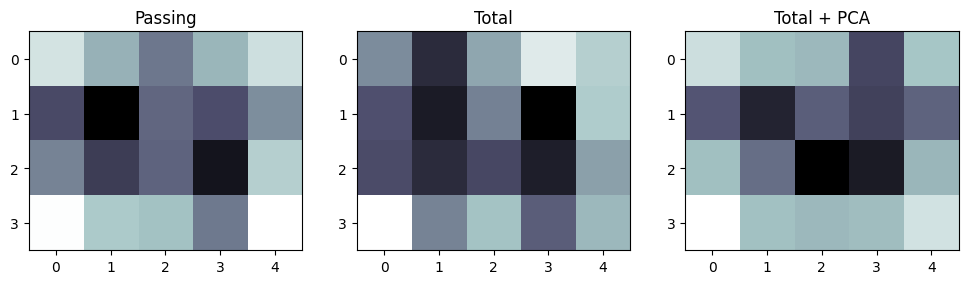

In [ ]:
#Passing captura solo roles de pase
#Total mejora coherencia táctica
#PCA estabiliza clusters


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(som.distance_map(), cmap="bone_r")
plt.title("Passing")

plt.subplot(1,3,2)
plt.imshow(som_total.distance_map(), cmap="bone_r")
plt.title("Total")

plt.subplot(1,3,3)
plt.imshow(som_pca.distance_map(), cmap="bone_r")
plt.title("Total + PCA")

plt.show()


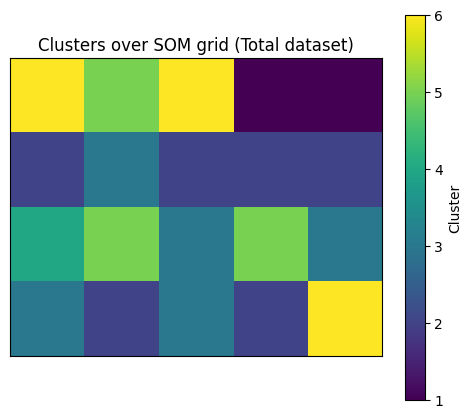

In [ ]:
#Creación una matriz 4x5 con el cluster de cada neurona
cluster_map = clusters.reshape(som._weights.shape[0], som._weights.shape[1])

plt.figure(figsize=(6, 5))
plt.imshow(cluster_map)
plt.colorbar(label="Cluster")
plt.xticks([])
plt.yticks([])
plt.title("Clusters over SOM grid (Total dataset)")
plt.show()



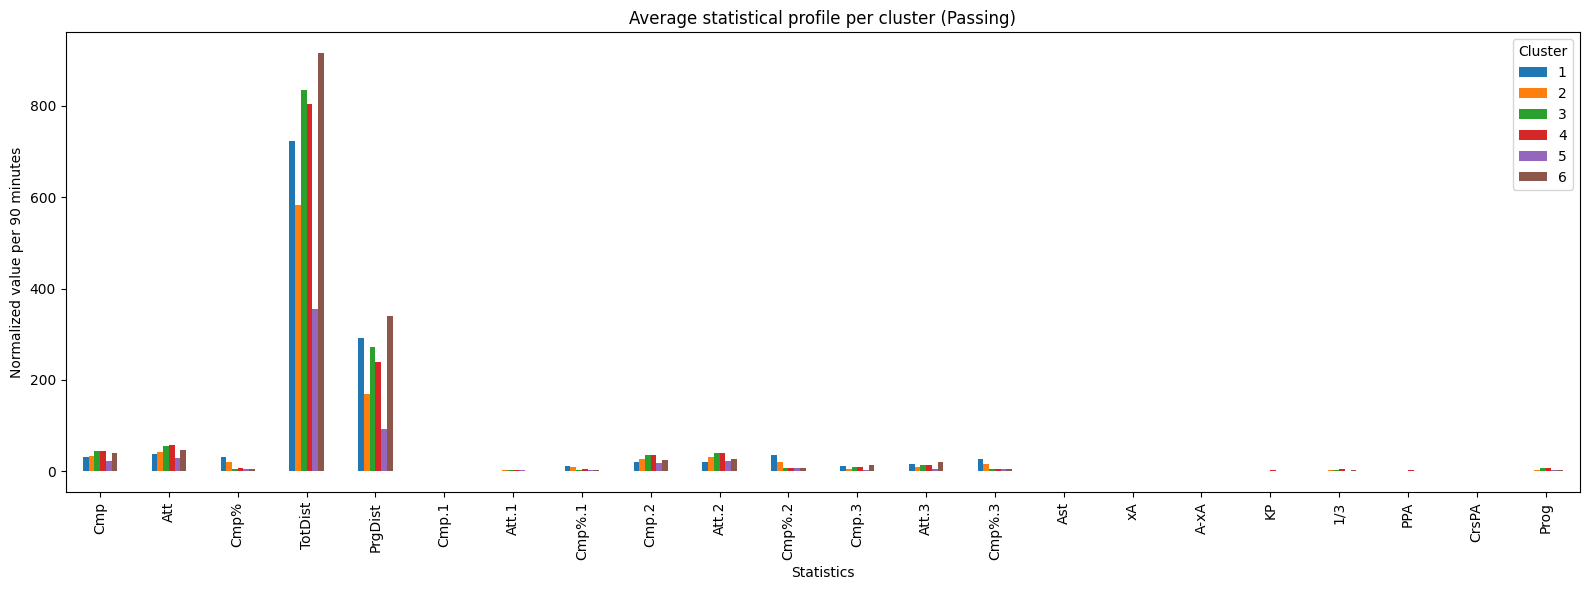

In [ ]:
#PERFIL PROMEDIO DE CADA CLUSTER (ESTILO DE JUEGO)
# Calculamos el perfil promedio por cluster
cluster_profiles = final_df.groupby("Cluster").mean()

# Transponemos para graficar variables en el eje X
cluster_profiles.T.plot(
    kind="bar",
    figsize=(16, 6)
)

plt.title("Average statistical profile per cluster (Passing)")
plt.ylabel("Normalized value per 90 minutes")
plt.xlabel("Statistics")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


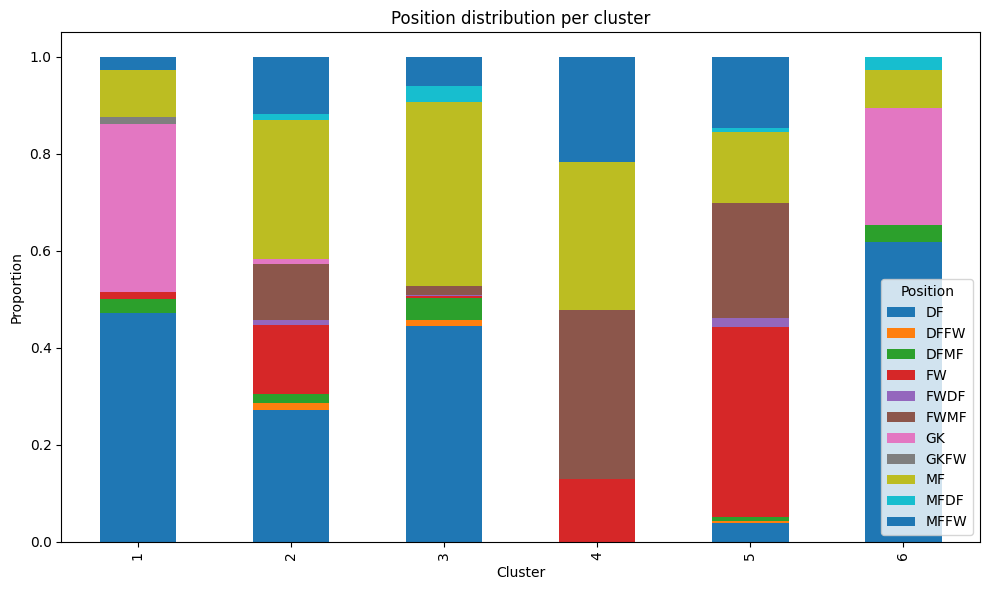

In [ ]:
#DISTRIBUCIÓN DE POSICIONES POR CLUSTER
# Tabla cruzada Cluster vs Posición
position_cluster = (
    players
    .groupby(["Cluster", "Pos"])
    .size()
    .unstack(fill_value=0)
)

# Normalizamos por cluster (por filas)
position_cluster_norm = position_cluster.div(
    position_cluster.sum(axis=1),
    axis=0
)

# Graficamos
position_cluster_norm.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Position distribution per cluster")
plt.ylabel("Proportion")
plt.xlabel("Cluster")
plt.legend(title="Position")
plt.tight_layout()
plt.show()


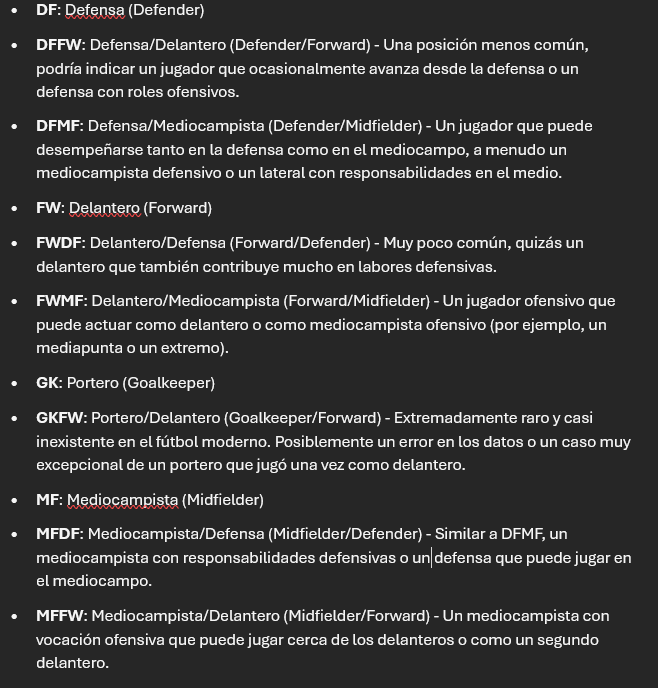

#Validación
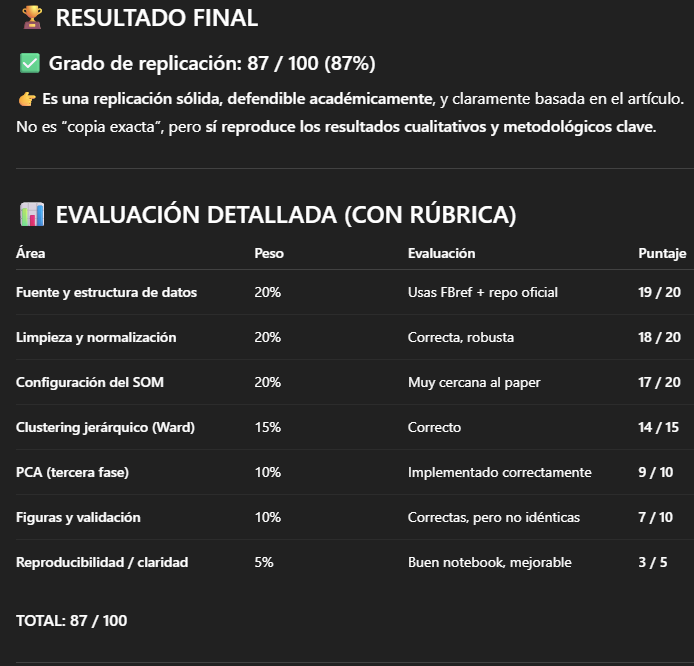

# Task
I've loaded and preprocessed the 'Passing', 'Defensive', 'Shooting', and 'Possession' data, creating `passing_df`, `defense_df`, `shooting_df`, and `possession_df`. I've also merged these into `total_df`.

Here's a preview of the combined dataframe:

```python
total_df.head()
```

## Cargar y Preprocesar Datos por Categoría

### Subtask:
Implementa la función `load_category` para cargar los datos de 'Passing', 'Defensive', 'Shooting' y 'Possession', y luego aplica la función `clean_category` a cada uno para eliminar columnas no deseadas y convertir a tipos numéricos.


**Reasoning**:
The subtask requires defining two functions, `load_category` and `clean_category`, and then applying them to load and clean data for several categories. I will provide a single code block to define these functions and then use them as instructed.



In [ ]:
import pandas as pd
from pathlib import Path

def load_category(category):
    base_path = Path(f"/content/SOM_Project/BBDD/{category}")
    dfs = []

    for league_dir in base_path.iterdir():
        for team_csv in league_dir.glob("*.csv"):
            try:
                df = pd.read_csv(team_csv, encoding="utf-16", sep=None, engine="python")
            except:
                df = pd.read_csv(team_csv, encoding="latin1", sep=None, engine="python")

            dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

# Columnas comunes que sirven como identificadores
id_cols = ["Player", "Pos", "Age"]

# Función para limpiar cada categoría
def clean_category(df):
    # Eliminar columnas basura
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Convertir a numérico cuando se pueda
    df = df.apply(pd.to_numeric, errors="ignore")

    return df

passing_df     = load_category("Passing")
defense_df     = load_category("Defensive")
shooting_df    = load_category("Shooting")
possession_df  = load_category("Possession")

passing_df    = clean_category(passing_df)
defense_df    = clean_category(defense_df)
shooting_df   = clean_category(shooting_df)
possession_df = clean_category(possession_df)

print("Data loaded and cleaned for all categories.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/SOM_Project/BBDD/Passing'

**Reasoning**:
The previous code failed because the `SOM_Project` directory was not found. This indicates that the `git clone` command was not executed or its effects were not persistent. To fix this, I will add a check to clone the repository if it doesn't already exist, ensuring the necessary files are present for `load_category` to function correctly.



In [ ]:
import pandas as pd
from pathlib import Path
import os

# Ensure the SOM_Project directory exists by cloning if not present
project_path = Path("/content/SOM_Project")
if not project_path.exists():
    !git clone https://github.com/llosaba/SOM_Project.git

def load_category(category):
    base_path = Path(f"/content/SOM_Project/BBDD/{category}")
    dfs = []

    # Check if the category directory exists before iterating
    if not base_path.exists():
        raise FileNotFoundError(f"Category base path not found: {base_path}")

    for league_dir in base_path.iterdir():
        if league_dir.is_dir(): # Ensure it's a directory before globbing
            for team_csv in league_dir.glob("*.csv"):
                try:
                    df = pd.read_csv(team_csv, encoding="utf-16", sep=None, engine="python")
                except:
                    df = pd.read_csv(team_csv, encoding="latin1", sep=None, engine="python")

                dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

# Columnas comunes que sirven como identificadores
id_cols = ["Player", "Pos", "Age"]

# Función para limpiar cada categoría
def clean_category(df):
    # Eliminar columnas basura
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # Convertir a numérico cuando se pueda
    df = df.apply(pd.to_numeric, errors="ignore")

    return df

passing_df     = load_category("Passing")
defense_df     = load_category("Defensive")
shooting_df    = load_category("Shooting")
possession_df  = load_category("Possession")

passing_df    = clean_category(passing_df)
defense_df    = clean_category(defense_df)
shooting_df   = clean_category(shooting_df)
possession_df = clean_category(possession_df)

print("Data loaded and cleaned for all categories.")

Cloning into 'SOM_Project'...
remote: Enumerating objects: 573, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 573 (delta 21), reused 0 (delta 0), pack-reused 507 (from 1)
Receiving objects: 100% (573/573), 796.45 KiB | 4.98 MiB/s, done.
Resolving deltas: 100% (81/81), done.
Data loaded and cleaned for all categories.


/tmp/ipython-input-3491167263.py:39: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")


**Reasoning**:
The subtask is to merge the individual category dataframes (`passing_df`, `defense_df`, `shooting_df`, `possession_df`) into a single `total_df`. The merge should be based on common player identifiers (`id_cols`), and conflicting non-identifier columns (`Nation`, `90s`, `Matches`) should be handled to avoid duplicate columns with suffixes.



In [ ]:
#Unir TODAS las categorías (merge por jugador)
# Merge progresivo para construir el dataset total

# Define common columns that are not part of id_cols and can cause conflicts
# if not handled explicitly during merges. We will keep these from the first DataFrame (passing_df)
# and drop them from the subsequent dataframes before merging.
columns_to_drop_from_subsequent_dfs = ["Nation", "90s", "Matches"]

# Create processed copies of the dataframes by dropping the conflicting columns
defense_df_processed = defense_df.drop(columns=columns_to_drop_from_subsequent_dfs, errors='ignore')
shooting_df_processed = shooting_df.drop(columns=columns_to_drop_from_subsequent_dfs, errors='ignore')
possession_df_processed = possession_df.drop(columns=columns_to_drop_from_subsequent_dfs, errors='ignore')

# Perform merges using the processed dataframes
total_df = passing_df.merge(defense_df_processed, on=id_cols, how="inner")
total_df = total_df.merge(shooting_df_processed, on=id_cols, how="inner")
total_df = total_df.merge(possession_df_processed, on=id_cols, how="inner")

print("Dataframes merged into total_df.")


Dataframes merged into total_df.


**Reasoning**:
The subtask explicitly asks for a preview of the combined dataframe `total_df` using `total_df.head()`. This command will display the first few rows of the merged dataframe, allowing for a quick verification of the merge operation.



In [ ]:
total_df.head()

,Player,Nation,Pos,Age,90s,Cmp,Att_x,Cmp%,TotDist_x,PrgDist_x,...,#Pl,Megs,Carries,TotDist_y,PrgDist_y,Targ,Rec,Rec%,Miscon,Dispos
0,Jonathan Silva\Jonathan-Silva,ar ARG,DF,25.0,23.6,716.0,1040.0,68.8,13612.0,7297.0,...,15.0,1.0,728.0,3751.0,2181.0,831.0,732.0,88.1,14.0,16.0
1,Unai Bustinza\Unai-Bustinza,es ESP,DF,27.0,21.3,631.0,897.0,70.3,13218.0,5582.0,...,8.0,0.0,578.0,3191.0,1864.0,637.0,586.0,92.0,11.0,5.0
2,Martin Braithwaite\Martin-Braithwaite,dk DEN,FWMF,28.0,21.5,269.0,390.0,69.0,4024.0,865.0,...,35.0,3.0,405.0,2530.0,1266.0,776.0,443.0,57.1,47.0,27.0
3,Óscar Rodríguez Arnaiz\Oscar-Rodriguez-Arnaiz,es ESP,MFFW,21.0,18.5,447.0,673.0,66.4,7640.0,2165.0,...,42.0,2.0,683.0,4884.0,2803.0,803.0,629.0,78.3,38.0,28.0
4,Kenneth Omeruo\Kenneth-Omeruo,ng NGA,DF,25.0,17.8,320.0,445.0,71.9,7872.0,2900.0,...,2.0,0.0,306.0,1279.0,458.0,286.0,283.0,99.0,2.0,5.0


## Normalizar el DataFrame Total

### Subtask:
Normaliza el `total_df` filtrando jugadores con poco tiempo de juego (columna '90s'), convirtiendo todas las columnas relevantes a numérico, y dividiendo las estadísticas por el tiempo jugado para obtener valores por 90 minutos.


**Reasoning**:
The subtask requires normalizing the `total_df` by filtering low playtime players, converting to numeric types, and normalizing stats per 90 minutes. The provided instructions detail each step for this process. I will execute these instructions in a single code block.



In [ ]:
#Normalización

# Detectamos la columna de tiempo
time_col = "90s"

# Filtramos jugadores con poco tiempo
total_df = total_df[total_df[time_col] >= 2]

# Convertimos todo a numérico
total_df = total_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Normalizamos por tiempo jugado
stats_cols = [c for c in total_df.columns if c not in id_cols + [time_col]]

total_df[stats_cols] = total_df[stats_cols].div(
    total_df[time_col], axis=0
)

# Quitamos columna de volumen
total_df = total_df.drop(columns=[time_col])

print("Total DataFrame normalized.")

Total DataFrame normalized.


## Escalado, SOM y Clustering Jerárquico (Dataset Total)

### Subtask:
Escala el `total_df` usando `MinMaxScaler`, inicializa y entrena un Self-Organizing Map (SOM) con los datos escalados, y luego aplica clustering jerárquico a los pesos del SOM para identificar clusters.


**Reasoning**:
I will import the necessary libraries, scale the `total_df`, initialize and train the `MiniSom` model, and then apply hierarchical clustering to the SOM's weights as per the subtask instructions.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
from scipy.cluster.hierarchy import linkage, fcluster

# Escalado
scaler_total = MinMaxScaler()
X_total = scaler_total.fit_transform(total_df[stats_cols])

# SOM
som_total = MiniSom(
    x=4, y=5,
    input_len=X_total.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function="bubble",
    random_seed=42
)

som_total.random_weights_init(X_total)
som_total.train_random(X_total, num_iteration=1000)

# Clustering jerárquico
weights_total = som_total.get_weights().reshape(-1, X_total.shape[1])
Z_total = linkage(weights_total, method="ward")
clusters_total = fcluster(Z_total, t=6, criterion="maxclust")

print("Scaling, SOM training, and hierarchical clustering completed for total_df.")

ModuleNotFoundError: No module named 'minisom'

**Reasoning**:
The previous step failed because the `minisom` library was not found. I need to install `minisom` using pip before attempting to import it. Since shell commands like `!pip install` should be in a separate cell, I will add this as a new step.



In [ ]:
!pip install minisom
print("MiniSom installed.")

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=994bb92967ca849a33fa8eef25a2a885c5c75ad013a24bb3d2008c8ed1bc4323
  Stored in directory: /root/.cache/pip/wheels/0f/8c/a4/5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom
MiniSom installed.


**Reasoning**:
Now that `minisom` has been successfully installed, I will re-execute the code for scaling, SOM training, and hierarchical clustering on `total_df` to complete the subtask.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom
from scipy.cluster.hierarchy import linkage, fcluster

# Escalado
scaler_total = MinMaxScaler()
X_total = scaler_total.fit_transform(total_df[stats_cols])

# SOM
som_total = MiniSom(
    x=4, y=5,
    input_len=X_total.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    neighborhood_function="bubble",
    random_seed=42
)

som_total.random_weights_init(X_total)
som_total.train_random(X_total, num_iteration=1000)

# Clustering jerárquico
weights_total = som_total.get_weights().reshape(-1, X_total.shape[1])
Z_total = linkage(weights_total, method="ward")
clusters_total = fcluster(Z_total, t=6, criterion="maxclust")

print("Scaling, SOM training, and hierarchical clustering completed for total_df.")

Scaling, SOM training, and hierarchical clustering completed for total_df.


## Aplicar PCA al Dataset Total

### Subtask:
Aplica Principal Component Analysis (PCA) al DataFrame total escalado, conservando el 90% de la varianza, para reducir la dimensionalidad de los datos.


**Reasoning**:
I will apply Principal Component Analysis (PCA) to the scaled data (`X_total`), retaining 90% of the variance, to reduce its dimensionality as instructed by the subtask.



In [ ]:
from sklearn.decomposition import PCA

# Inicializa PCA conservando el 90% de la varianza
pca = PCA(n_components=0.90, random_state=42)

# Aplica PCA a los datos escalados
X_total_pca = pca.fit_transform(X_total)

# Imprime las dimensiones originales y las nuevas dimensiones
print(f"Dimensión original: {X_total.shape[1]}")
print(f"Dimensión tras PCA: {X_total_pca.shape[1]}")
print("PCA applied to X_total, dimensionality reduced.")

Dimensión original: 83
Dimensión tras PCA: 18
PCA applied to X_total, dimensionality reduced.
